In [8]:
import os
print(os.getcwd())

/home/ipk410/Alireza/RynnBrain/RynnBrain/scripts


In [9]:
import os

# Root project directory
PROJECT_DIR = "/home/ipk410/Alireza/RynnBrain/RynnBrain"

# Important folders
SCRIPTS_DIR = os.path.join(PROJECT_DIR, "scripts")
DATA_DIR = os.path.join(PROJECT_DIR, "data")
HF_CACHE = os.path.join(PROJECT_DIR, "hf_cache")

# Create folders if missing
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(HF_CACHE, exist_ok=True)

# HuggingFace cache setup
os.environ["HF_HOME"] = HF_CACHE
os.environ["HF_HUB_CACHE"] = os.path.join(HF_CACHE, "hub")
os.environ["TRANSFORMERS_CACHE"] = HF_CACHE

print("PROJECT_DIR =", PROJECT_DIR)
print("DATA_DIR =", DATA_DIR)
print("HF_CACHE =", HF_CACHE)

PROJECT_DIR = /home/ipk410/Alireza/RynnBrain/RynnBrain
DATA_DIR = /home/ipk410/Alireza/RynnBrain/RynnBrain/data
HF_CACHE = /home/ipk410/Alireza/RynnBrain/RynnBrain/hf_cache


In [13]:
pip install torch transformers accelerate datasets pillow matplotlib opencv-python ipykernel notebook

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 797.1/797.1 MB 35.2 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 37.5 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 32.2 MB/s eta 0:00:0031m33.1 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 32.4 MB/s eta 0:00:00 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 29.9 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 29.7 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 32.3 MB/s eta 0:00:00 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 38.6 MB/s eta 0:00:000:00:01m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 32.3 MB/s eta 0:00:00m eta 0:00:010:01:01
   ━━━━━━━━━━━━

In [23]:
!pip install -U transformers accelerate safetensors huggingface_hub sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 17.3 MB/s eta 0:00:00


In [10]:
import torch

print(torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 3080 Ti


In [11]:
import torch
from transformers import AutoProcessor, AutoModelForImageTextToText

model_path = "/home/ipk410/Alireza/RynnBrain/RynnBrain/hf_cache/RynnBrain-CoP-8B"

processor = AutoProcessor.from_pretrained(
    model_path,
    trust_remote_code=True
)

model = AutoModelForImageTextToText.from_pretrained(
    model_path,
    device_map="auto",
    torch_dtype=torch.float16,
    low_cpu_mem_usage=True,
    trust_remote_code=True
)

print("CoP model loaded successfully.")

Loading weights: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 750/750 [00:03<00:00, 210.23it/s]


CoP model loaded successfully.


In [12]:
import sys
!"{sys.executable}" -m pip install datasets

In [13]:
import datasets
print(datasets.__version__)

4.8.5


In [14]:
from datasets import load_dataset

dataset = load_dataset(
    "Henri09IPK/SteriBot_Failsense",
    cache_dir=r"E:\Master - Polimi\Thesis\Practical steps\data"
)

print(dataset)

print(dataset["test"][0])

DatasetDict({
    test: Dataset({
        features: ['images', 'task', 'label', 'image_name'],
        num_rows: 53
    })
})
{'images': <PIL.Image.Image image mode=RGB size=2000x413 at 0x7F595DB6A3E0>, 'task': 'move the red pen', 'label': 'success', 'image_name': 'minimal_translation_stable'}


In [15]:
sample = dataset["test"][0]

print(sample.keys())

dict_keys(['images', 'task', 'label', 'image_name'])


In [16]:
print(sample["task"])
print(sample["label"])
print(sample["image_name"])

move the red pen
success
minimal_translation_stable


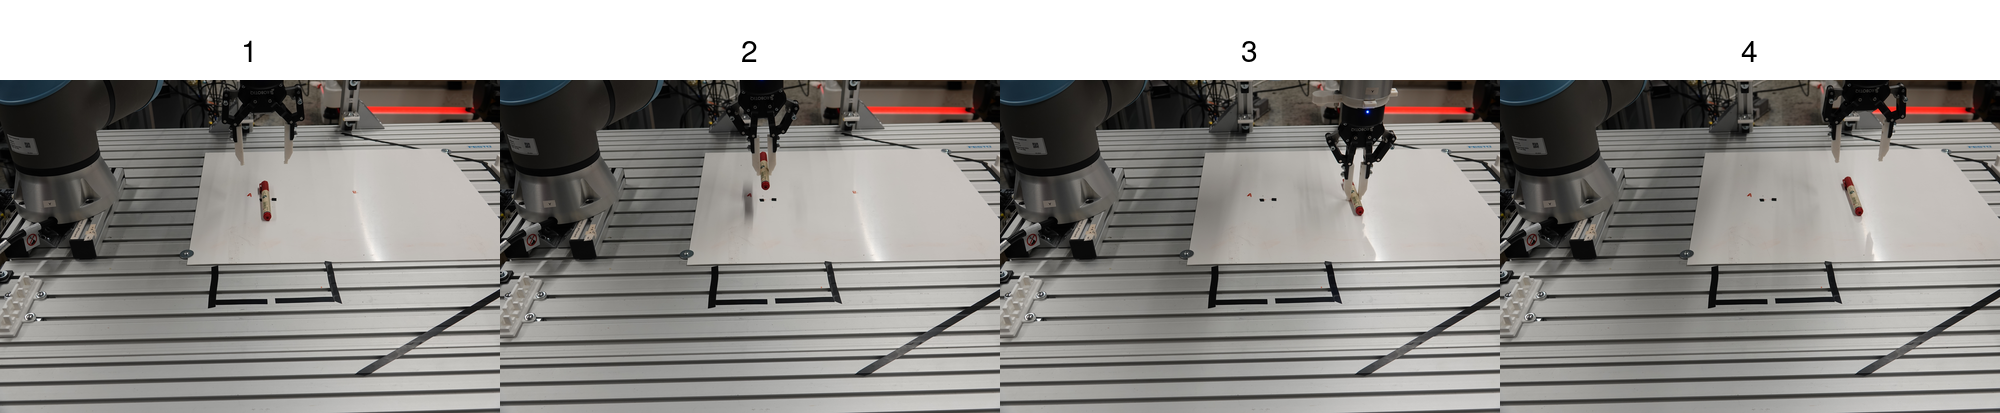

In [17]:
sample["images"]

In [18]:
from collections import Counter

labels = [dataset["test"][i]["label"] for i in range(len(dataset["test"]))]
print(Counter(labels))

Counter({'success': 28, 'fail': 25})


In [19]:
sample = dataset["test"][0]

img = sample["images"]
print(type(img))
print(img.size)
print(sample["task"])
print(sample["label"])
print(sample["image_name"])

<class 'PIL.Image.Image'>
(2000, 413)
move the red pen
success
minimal_translation_stable


In [20]:
import os

save_dir = r"E:\Master - Polimi\Thesis\Practical steps\data\sample_images"
os.makedirs(save_dir, exist_ok=True)

sample = dataset["test"][0]
img = sample["images"]

image_path = os.path.join(save_dir, sample["image_name"] + ".jpg")
img.save(image_path)

print(image_path)

E:\Master - Polimi\Thesis\Practical steps\data\sample_images/minimal_translation_stable.jpg


In [21]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

True
NVIDIA GeForce RTX 3080 Ti


In [22]:
import torch
from transformers import AutoModelForImageTextToText, AutoProcessor

model_path = "Alibaba-DAMO-Academy/RynnBrain-2B"
cache_dir = r"E:\Master - Polimi\Thesis\Practical steps\RynnBrain\hf_cache"

processor = AutoProcessor.from_pretrained(model_path, cache_dir=cache_dir)

model = AutoModelForImageTextToText.from_pretrained(
    model_path,
    cache_dir=cache_dir,
    torch_dtype=torch.float32,
    low_cpu_mem_usage=True
)

Loading weights: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 626/626 [00:01<00:00, 348.09it/s]


In [37]:
image_path = r"/home/ipk410/Alireza/RynnBrain/RynnBrain/data/minimal_translation_stable.jpg"

conversation = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image_path},
            {
                "type": "text",
                "text": (
                    "This image shows a robotic manipulation task. "
                    "The task is: move the red pen. "
                    "Does the execution look successful or failed? "
                    "Answer with only one word: success or failure."
                ),
            },
        ],
    }
]


model_inputs = processor.apply_chat_template(
    conversation,
    add_generation_prompt=True,
    tokenize=True,
    return_dict=True,
    return_tensors="pt",
)

model_inputs = model_inputs.to(model.device)

with torch.no_grad():
    output_ids = model.generate(
        **model_inputs,
        max_new_tokens=128,
    )

output_ids = output_ids[:, model_inputs["input_ids"].shape[1]:]
response = processor.decode(output_ids[0], skip_special_tokens=True)

print(response)

print("Ground truth:", sample["label"])
print("RynnBrain prediction:", response)

ValueError: Incorrect image source. Must be a valid URL starting with `http://` or `https://`, a valid path to an image file, or a base64 encoded string. Got /home/ipk410/Alireza/RynnBrain/RynnBrain/data/minimal_translation_stable.jpg. Failed with Invalid base64-encoded string: number of data characters (73) cannot be 1 more than a multiple of 4

First failure index: 6
Task: move the object to the left
Label: fail
Image name: minimal_translation_stable


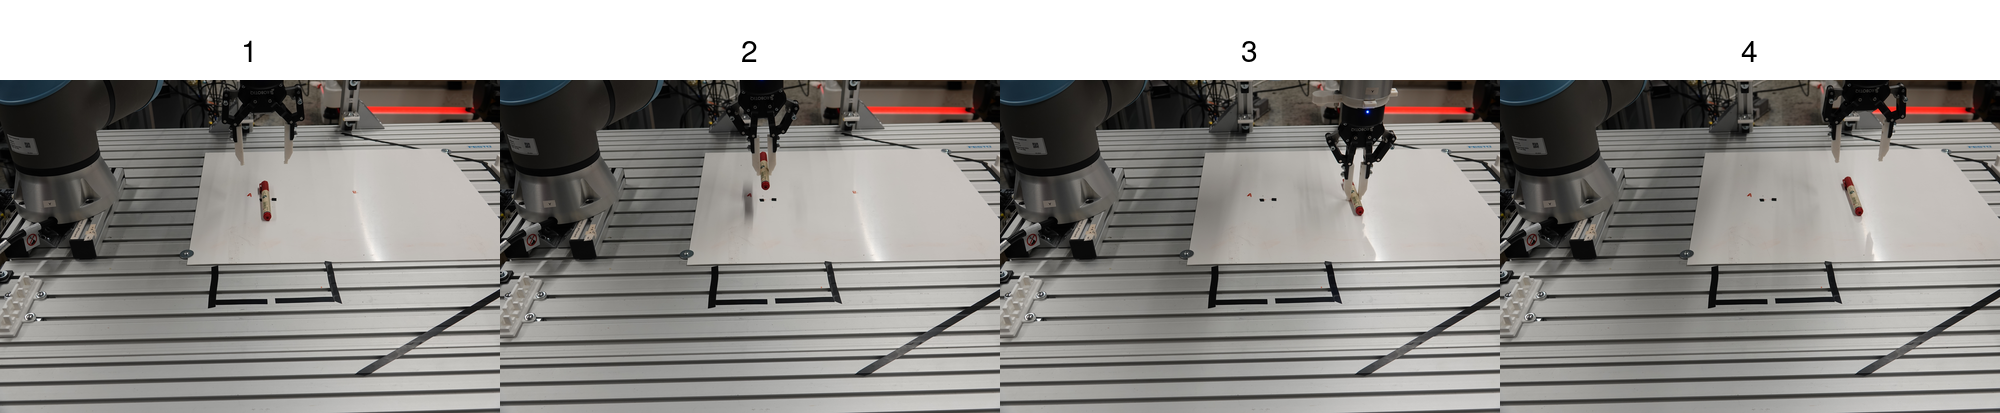

In [20]:
# Find first failure sample
fail_idx = None

for i in range(len(dataset["test"])):
    if dataset["test"][i]["label"] == "fail":
        fail_idx = i
        break

print("First failure index:", fail_idx)

fail_sample = dataset["test"][fail_idx]

print("Task:", fail_sample["task"])
print("Label:", fail_sample["label"])
print("Image name:", fail_sample["image_name"])

fail_sample["images"]

In [25]:
import os

save_dir = r"data\sample_images"
os.makedirs(save_dir, exist_ok=True)

fail_image_path = os.path.join(save_dir, fail_sample["image_name"] + ".jpg")
fail_sample["images"].save(fail_image_path)

print(fail_image_path)

NameError: name 'fail_sample' is not defined

In [27]:
image_path = fail_image_path

conversation = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image_path},
            {
                "type": "text",
                "text": (
                    f"This image shows a robotic manipulation task. "
                    f"The task is: {fail_sample['task']}. "
                    "Does the execution look successful or failed? "
                    "Answer with only one word: success or fail."
                ),
            },
        ],
    }
]

model_inputs = processor.apply_chat_template(
    conversation,
    add_generation_prompt=True,
    tokenize=True,
    return_dict=True,
    return_tensors="pt",
)

model_inputs = model_inputs.to(model.device)

with torch.no_grad():
    output_ids = model.generate(
        **model_inputs,
        max_new_tokens=128,
    )

output_ids = output_ids[:, model_inputs["input_ids"].shape[1]:]
response = processor.decode(output_ids[0], skip_special_tokens=True)

print(response)

print("Ground truth:", fail_sample["label"])
print("RynnBrain prediction:", response)

NameError: name 'fail_image_path' is not defined

In [26]:
print("Ground truth:", fail_sample["label"])
print("RynnBrain prediction:", response)

Ground truth: fail
RynnBrain prediction: fail


In [41]:
image_path = fail_image_path

conversation = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": fail_sample["images"]
            },
            {
                "type": "text",
                "text": (
                    f"This image sequence shows a robotic manipulation task.\n"
                    f"The commanded task is: {fail_sample['task']}.\n"
                    "Judge whether the final state satisfies the commanded task.\n"
                    "Return your answer in this exact format:\n"
                    "Prediction: success or fail\n"
                    "Reason: one short sentence explaining the visual evidence."
                ),
            },
        ],
    }
]

model_inputs = processor.apply_chat_template(
    conversation,
    add_generation_prompt=True,
    tokenize=True,
    return_dict=True,
    return_tensors="pt",
)

model_inputs = model_inputs.to(model.device)

with torch.no_grad():
    output_ids = model.generate(
        **model_inputs,
        max_new_tokens=256,
    )

output_ids = output_ids[:, model_inputs["input_ids"].shape[1]:]
response = processor.decode(output_ids[0], skip_special_tokens=True)

print(response)

print("Ground truth:", fail_sample["label"])
print("RynnBrain prediction:", response)

fail
Ground truth: fail
RynnBrain prediction: fail


In [43]:
image_path = fail_image_path

conversation = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": fail_sample["images"]
            },
            {
                "type": "text",
                "text": (
                            f"This image sequence shows a robotic manipulation task.\n"
                            f"The commanded task is: {fail_sample['task']}.\n"
                            "Describe whether the final state satisfies the command and explain the visual evidence in one sentence."
                        ),
            },
        ],
    }
]

model_inputs = processor.apply_chat_template(
    conversation,
    add_generation_prompt=True,
    tokenize=True,
    return_dict=True,
    return_tensors="pt",
)

model_inputs = model_inputs.to(model.device)

with torch.no_grad():
    output_ids = model.generate(
        **model_inputs,
        max_new_tokens=256,
    )

output_ids = output_ids[:, model_inputs["input_ids"].shape[1]:]
response = processor.decode(output_ids[0], skip_special_tokens=True)

print(response)

print("Ground truth:", fail_sample["label"])
print("RynnBrain prediction:", response)

Yes, the object is elevated. The grasped object is lifted above the table.
Ground truth: fail
RynnBrain prediction: Yes, the object is elevated. The grasped object is lifted above the table.


In [35]:
image_path = fail_image_path

conversation = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": fail_sample["images"]
            },
            {
                "type": "text",
                "text": (
                            f"This image sequence shows a robotic manipulation task.\n"
                            "Describe what you see exactly."
                        ),
            },
        ],
    }
]

model_inputs = processor.apply_chat_template(
    conversation,
    add_generation_prompt=True,
    tokenize=True,
    return_dict=True,
    return_tensors="pt",
)

model_inputs = model_inputs.to(model.device)

with torch.no_grad():
    output_ids = model.generate(
        **model_inputs,
        max_new_tokens=256,
    )

output_ids = output_ids[:, model_inputs["input_ids"].shape[1]:]
response = processor.decode(output_ids[0], skip_special_tokens=True)

print(response)

print("Ground truth:", fail_sample["label"])
print("RynnBrain prediction:", response)

NameError: name 'image' is not defined

In [46]:
image_path = fail_image_path

conversation = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": fail_sample["images"]
            },
            {
                "type": "text",
                "text": (
                            f"This image contains four ordered frames of the same robotic manipulation attempt, "
                            f"from left to right: frame 1, frame 2, frame 3, and frame 4.\n"
                            f"The commanded task is: {fail_sample['task']}.\n"
                            "Analyze the sequence from left to right and judge whether the final frame satisfies the commanded task.\n"
                            "Return your answer in this format:\n"
                            "Prediction: success or fail\n"
                            "Reason: explain using the final frame and the commanded task."
                        ),
            },
        ],
    }
]

model_inputs = processor.apply_chat_template(
    conversation,
    add_generation_prompt=True,
    tokenize=True,
    return_dict=True,
    return_tensors="pt",
)

model_inputs = model_inputs.to(model.device)

with torch.no_grad():
    output_ids = model.generate(
        **model_inputs,
        max_new_tokens=256,
    )

output_ids = output_ids[:, model_inputs["input_ids"].shape[1]:]
response = processor.decode(output_ids[0], skip_special_tokens=True)

print(response)

print("Ground truth:", fail_sample["label"])
print("RynnBrain prediction:", response)

Prediction: fail
Ground truth: fail
RynnBrain prediction: Prediction: fail


In [34]:
import sys
!"{sys.executable}" -m pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/8.2 MB 6.0 MB/s eta 0:00:02
   ----------- ---------------------------- 2.4/8.2 MB 6.2 MB/s eta 0:00:01
   ---------------- ----------------------- 3.4/8.2 MB 5.7 MB/s eta 0:00:01
   ---------------------- ----------------- 4.7/8.2 MB 5.9 MB/s eta 0:00:01
   ----------------------------- ---------- 6.0/8.2 MB 6.1 MB/s eta 0:00:01
   ---------------------------------- ----- 7.1/8.2 MB 5.9 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 5.8 MB/s  0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------- ----------------- 1.3/2.3 MB 7.1 MB/s eta 0:00:01
   ----------------------------------- ---- 2.1/2.3 MB 5.8 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 5.5 MB/s 

Sample index: 7
Task: move the object upwards
Ground truth: fail
Prediction: Yes, the object is elevated. The grasped object is lifted above the table.
Image name: minimal_translation_stable


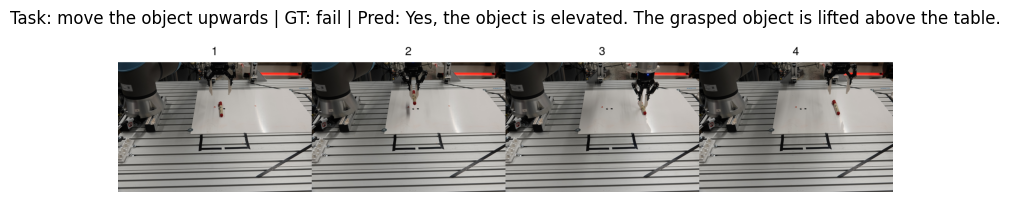

In [44]:
import matplotlib.pyplot as plt

print("Sample index:", fail_idx)
print("Task:", fail_sample["task"])
print("Ground truth:", fail_sample["label"])
print("Prediction:", response)
print("Image name:", fail_sample["image_name"])

plt.figure(figsize=(10, 4))
plt.imshow(fail_sample["images"])
plt.axis("off")
plt.title(
    f"Task: {fail_sample['task']} | "
    f"GT: {fail_sample['label']} | "
    f"Pred: {response}"
)
plt.show()

In [28]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.device_count())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

True
1
NVIDIA GeForce RTX 3080 Ti


In [29]:
# Find next failure sample after the previous one
next_fail_idx = None

for i in range(fail_idx + 1, len(dataset["test"])):
    if dataset["test"][i]["label"] == "fail":
        next_fail_idx = i
        break

print("Next failure index:", next_fail_idx)

fail_idx = next_fail_idx
fail_sample = dataset["test"][fail_idx]

print("Task:", fail_sample["task"])
print("Label:", fail_sample["label"])
print("Image name:", fail_sample["image_name"])

fail_sample["images"]

NameError: name 'fail_idx' is not defined

In [30]:
import sys
!"{sys.executable}" -m pip install torchcodec

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 27.1 MB/s  0:00:00


In [31]:
#Extract frames from the video and feed them as images. Because I don't have enough GPU

import sys
!"{sys.executable}" -m pip install opencv-python

In [32]:
import cv2
from PIL import Image

def extract_frames(video_path, num_frames=4):
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    frame_indices = [
        int(i * (total_frames - 1) / (num_frames - 1))
        for i in range(num_frames)
    ]

    frames = []

    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()

        if ret:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(Image.fromarray(frame))

    cap.release()
    return frames

In [33]:
video_path = r"E:\Master - Polimi\Thesis\Practical steps\data\videos\i10_pick_place.mp4"

frames = extract_frames(video_path, num_frames=4)

frames[3]

IndexError: list index out of range

In [59]:
# Use the frames extracted from the video
# frames = extract_frames(video_path, num_frames=4)

conversation = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": frames[0]},
            {"type": "image", "image": frames[1]},
            {"type": "image", "image": frames[2]},
            {"type": "image", "image": frames[3]},
            {
                "type": "text",
                "text": (
                    "These are four ordered frames from the same robotic manipulation video. "
                    "The frames are ordered from first to last. "
                    "Describe what happens in the sequence, focusing on the robot, the object, "
                    "and the final state of the task."
                ),
            },
        ],
    }
]

model_inputs = processor.apply_chat_template(
    conversation,
    add_generation_prompt=True,
    tokenize=True,
    return_dict=True,
    return_tensors="pt",
)

model_inputs = model_inputs.to(model.device)

with torch.no_grad():
    output_ids = model.generate(
        **model_inputs,
        max_new_tokens=256,
    )

output_ids = output_ids[:, model_inputs["input_ids"].shape[1]:]
response = processor.decode(output_ids[0], skip_special_tokens=True)

print(response)

The robot moves towards the object and grasps it.


In [ ]:
from PIL import Image
import torch

image_path = os.path.join(DATA_DIR, "fail_example.png")

image = Image.open(image_path).convert("RGB")

conversation = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": image
            },
            {
                "type": "text",
                "text": (
                    "This image contains four ordered frames of the same robotic manipulation attempt, "
                    "from left to right: frame 1, frame 2, frame 3, and frame 4.\n"
                    "Analyze the sequence from left to right and determine whether the task succeeded or failed.\n"
                    "Return your answer in this format:\n"
                    "Prediction: success or fail\n"
                    "Reason: explain briefly."
                ),
            },
        ],
    }
]

model_inputs = processor.apply_chat_template(
    conversation,
    add_generation_prompt=True,
    tokenize=True,
    return_dict=True,
    return_tensors="pt",
)

model_inputs = model_inputs.to(model.device)

with torch.no_grad():
    output_ids = model.generate(
        **model_inputs,
        max_new_tokens=256,
    )

output_ids = output_ids[:, model_inputs["input_ids"].shape[1]:]

response = processor.decode(
    output_ids[0],
    skip_special_tokens=True
)

print(response)

In [39]:
from PIL import Image
import torch

image_path = "/home/ipk410/Alireza/RynnBrain/RynnBrain/data/sample_images/minimal_translation_stable.jpg"

image = Image.open(image_path).convert("RGB")

conversation = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {
                "type": "text",
                "text": (
                    "This image shows a robotic manipulation task.\n"
                    "The task is: move the red pen.\n"
                    "Does the execution look successful or failed?\n"
                    "Answer with only one word: success or failure."
                ),
            },
        ],
    }
]

model_inputs = processor.apply_chat_template(
    conversation,
    add_generation_prompt=True,
    tokenize=True,
    return_dict=True,
    return_tensors="pt",
)

model_inputs = model_inputs.to(model.device)

with torch.no_grad():
    output_ids = model.generate(
        **model_inputs,
        max_new_tokens=128,
    )

output_ids = output_ids[:, model_inputs["input_ids"].shape[1]:]

response = processor.decode(
    output_ids[0],
    skip_special_tokens=True
)

print(response)

failure
